In [ ]:
# Load model directly
from transformers import AutoProcessor, AutoModelForImageTextToText, MllamaForConditionalGeneration
from PIL import Image
import torch
import numpy as np

model_id = "meta-llama/Llama-3.2-11B-Vision-Instruct"

processor = AutoProcessor.from_pretrained(model_id)
model = AutoModelForImageTextToText.from_pretrained(model_id, torch_dtype=torch.bfloat16, device_map="auto")
# model = MllamaForConditionalGeneration.from_pretrained(model_id,torch_dtype=torch.bfloat16,device_map="auto")

OSError: There was a specific connection error when trying to load meta-llama/Llama-3.2-11B-Vision-Instruct:
401 Client Error: Unauthorized for url: https://huggingface.co/meta-llama/Llama-3.2-11B-Vision-Instruct/resolve/main/processor_config.json (Request ID: Root=1-68594ad9-260bd7b32033bd0c23c961be;7cdb34d0-65a1-427e-ba79-a1ae34df748f)

Invalid credentials in Authorization header

In [ ]:
print(model)

NameError: name 'model' is not defined

In [ ]:
import torch
from PIL import Image

# Dictionaries to store the outputs from hooks
attentions = {}
layer_embeddings = {}

# A helper function to create a hook that saves output in a dictionary.
def get_hook(name, store_dict):
    def hook(module, input, output):
        store_dict[name] = output
    return hook

# --- Register Hooks for the Language Model ---

# For each language model layer, check if it has a self-attention or cross-attention module.
for idx, layer in enumerate(model.language_model.model.layers):
    if hasattr(layer, 'self_attn'):
        # Hook the self-attention outputs if available.
        layer.self_attn.register_forward_hook(get_hook(f"lang_layer_{idx}_attn", attentions))
    elif hasattr(layer, 'cross_attn'):
        # For cross-attention layers, hook the cross-attention outputs.
        layer.cross_attn.register_forward_hook(get_hook(f"lang_layer_{idx}_attn", attentions))
    else:
        print(f"Layer {idx} has no attention module to hook.")

    # Hook the entire layer output (i.e. the hidden state after the layer)
    layer.register_forward_hook(get_hook(f"lang_layer_{idx}_embedding", layer_embeddings))

# --- Register Hooks for the Vision Model ---

# For the main vision transformer layers
for idx, layer in enumerate(model.vision_model.transformer.layers):
    layer.self_attn.register_forward_hook(get_hook(f"vision_layer_{idx}_attn", attentions))
    layer.register_forward_hook(get_hook(f"vision_layer_{idx}_embedding", layer_embeddings))

# Optionally, if you want to hook the global vision transformer layers as well:
for idx, layer in enumerate(model.vision_model.global_transformer.layers):
    layer.self_attn.register_forward_hook(get_hook(f"global_vision_layer_{idx}_attn", attentions))
    layer.register_forward_hook(get_hook(f"global_vision_layer_{idx}_embedding", layer_embeddings))

# --- Prepare Input Data ---

# Load your image (update the path as needed)
image = Image.open('../temp_image2.jpg')
prompt = """
Imagine you are a person with the following specific details (origin, age, gender, professional background, mental workload, emotion):

Nigeria, 65 or older, male, Recreational Participant, high, fear

You are observing the provided image. Based on your details, rate how interesting you find this image by selecting only one of the following options:
"Not Interesting," "Slightly Interesting," "Moderately Interesting," "Very Interesting," or "Extremely Interesting".

Provide a brief explanation in one short sentence without going into excessive detail. Present the output as a JSON object in the following format:
{
    "interestingness": "...",
    "explanation": "..."
}
"""
# Prepare a message that includes both image and text (adjust if needed)
messages = [
    {
        "role": "user",
        "content": [
            {"type": "image"},
            {"type": "text", "text": prompt}
        ]
    }
]

# Create the input text prompt using your processor (adjust parameters if needed)
input_text = processor.apply_chat_template(messages, add_generation_prompt=False)

# Process the image and text input into tensors and send them to the model device
inputs = processor(image, input_text, add_special_tokens=False, return_tensors="pt").to(model.device)

# --- Forward Pass with Hooks Active ---

# Generate the response (this will trigger the hooks)
with torch.no_grad():
    generated_ids = model.generate(**inputs, max_length=1000)

# Decode the generated tokens into text.
response_text = processor.tokenizer.decode(generated_ids[0], skip_special_tokens=True)
print("Generated Response:")
print(response_text)

# A small helper to print shapes whether the hook output is a tensor or a tuple.
def get_shape(value):
    if isinstance(value, tuple):
        return value[0].shape
    return value.shape

# --- Access the Saved Attentions and Embeddings ---

print("Collected Attention Outputs:")
for key, value in attentions.items():
    print(f"{key}: {get_shape(value)}")

print("\nCollected Layer Embeddings:")
for key, value in layer_embeddings.items():
    print(f"{key}: {get_shape(value)}")


NameError: name 'model' is not defined

In [ ]:
attentions

{'vision_layer_0_attn': (tensor([[[-2.1680e-01, -3.5858e-03, -3.8574e-02,  ...,  2.1680e-01,
             2.3842e-04,  2.8906e-01],
           [-5.6250e-01, -2.5977e-01, -3.3398e-01,  ...,  2.2656e-01,
             6.2866e-03,  5.0781e-01],
           [-4.6680e-01, -1.1621e-01, -1.9824e-01,  ...,  2.3242e-01,
             1.7334e-02,  4.5117e-01],
           ...,
           [-6.3281e-01,  5.2002e-02,  2.0508e-01,  ...,  7.2754e-02,
            -2.6978e-02, -3.5889e-02],
           [-6.3281e-01,  5.2002e-02,  2.0508e-01,  ...,  7.2754e-02,
            -2.6978e-02, -3.5889e-02],
           [-6.3281e-01,  5.2002e-02,  2.0508e-01,  ...,  7.2754e-02,
            -2.6978e-02, -3.5889e-02]]], device='cuda:0', dtype=torch.bfloat16),
  None),
 'vision_layer_1_attn': (tensor([[[-0.0718,  0.0684, -0.0114,  ...,  0.1572,  0.0364,  0.0247],
           [-0.0608, -0.0496, -0.2227,  ...,  0.1641, -0.0160,  0.0047],
           [ 0.1348, -0.0342, -0.1064,  ...,  0.1118,  0.0596,  0.0070],
           ...

Attention array shape: (6432, 1280)
Embedding array shape: (6432, 1280)


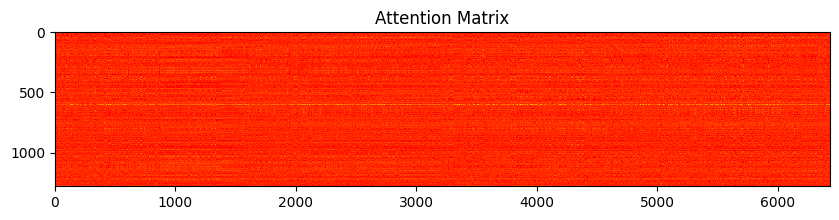

In [ ]:
i = 30
#  Get the vision_layer_0_attn as well as the vision_layer_0_embedding outputs
vision_layer_0_attn = attentions[f"vision_layer_{i}_attn"][0]
vision_layer_0_embedding = layer_embeddings[f"vision_layer_{i}_embedding"][0]

# Convert the attention matrix to a numpy array for visualization
attention_array = vision_layer_0_attn.to(torch.float32).cpu().numpy()
embedding_array = vision_layer_0_embedding.to(torch.float32).cpu().numpy()

attention_array = attention_array[0] # Remove the batch dimension
embedding_array = embedding_array[0] # Remove the batch dimension

# Print the shapes of the attention and embedding arrays
print("Attention array shape:", attention_array.shape)
print("Embedding array shape:", embedding_array.shape)

# Visualize the attention matrix
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 10))
plt.imshow(attention_array.T, cmap='hot', interpolation='nearest')
plt.title("Attention Matrix")
# plt.colorbar()
plt.show()

In [ ]:
loaded_results = np.load('/nasdata/abdu/demographics/results-FAU.npy', allow_pickle=True).item()
results_list = loaded_results['results']

In [ ]:
results_list

[{'user_id': np.int64(2255),
  'img_id': np.int64(1),
  'interestingness': 'Moderately Interesting',
  'explanation': 'The image shows a group of older people posing for a photo, which might be interesting to someone from Nigeria who is 65 or older and has a high mental workload and is feeling fearful.',
  'embeddings': {'vision_layer_0_embedding': array([[-0.1015625 ,  0.13867188,  0.14648438, ...,  0.14746094,
           -0.10546875,  0.36523438],
          [ 0.25      ,  0.13378906,  0.01660156, ..., -0.11328125,
            0.03393555,  0.4921875 ],
          [-0.578125  ,  0.13867188, -0.11523438, ...,  0.08300781,
            0.29296875,  0.29101562],
          ...,
          [ 4.84375   , -0.07470703, -0.359375  , ...,  1.6015625 ,
           -0.16796875, -1.0546875 ],
          [ 4.84375   , -0.07470703, -0.359375  , ...,  1.6015625 ,
           -0.16796875, -1.0546875 ],
          [ 4.84375   , -0.07470703, -0.359375  , ...,  1.6015625 ,
           -0.16796875, -1.0546875 ]], 

In [ ]:
i = 4
# Print the key 'user_id' from the first result
print(results_list[i]['user_id'])
print(results_list[i]['img_id'])
print(results_list[i]['interestingness'])
print(results_list[i]['explanation'])
print(results_list[i]['embeddings'])

2255
5
Moderately Interesting
The image appears to be a professional setting, possibly a meeting or conference, which might be moderately interesting to someone like me who is not familiar with the context or the individuals involved.
{'vision_layer_0_embedding': array([[-0.02148438,  0.14257812,  0.12597656, ...,  0.14355469,
        -0.12695312,  0.359375  ],
       [ 0.66015625,  0.0390625 , -0.04833984, ...,  0.4921875 ,
         0.48046875,  0.6015625 ],
       [ 0.78125   ,  0.07714844,  0.75390625, ...,  0.51953125,
         0.37890625,  0.62109375],
       ...,
       [ 5.46875   ,  0.04467773, -0.47851562, ...,  1.875     ,
        -0.30273438, -1.0078125 ],
       [ 5.46875   ,  0.04467773, -0.47851562, ...,  1.875     ,
        -0.30273438, -1.0078125 ],
       [ 5.46875   ,  0.04467773, -0.47851562, ...,  1.875     ,
        -0.30273438, -1.0078125 ]], shape=(6432, 1280), dtype=float32), 'vision_layer_1_embedding': array([[-1.3828125 ,  0.07617188,  0.03149414, ...,  0.2128

In [ ]:
for key in results_list[i]['embeddings']:
    print(key, results_list[i]['embeddings'][key].shape)

vision_layer_0_embedding (6432, 1280)
vision_layer_1_embedding (6432, 1280)
vision_layer_2_embedding (6432, 1280)
vision_layer_3_embedding (6432, 1280)
vision_layer_4_embedding (6432, 1280)
vision_layer_5_embedding (6432, 1280)
vision_layer_6_embedding (6432, 1280)
vision_layer_7_embedding (6432, 1280)
vision_layer_8_embedding (6432, 1280)
vision_layer_9_embedding (6432, 1280)
vision_layer_10_embedding (6432, 1280)
vision_layer_11_embedding (6432, 1280)
vision_layer_12_embedding (6432, 1280)
vision_layer_13_embedding (6432, 1280)
vision_layer_14_embedding (6432, 1280)
vision_layer_15_embedding (6432, 1280)
vision_layer_16_embedding (6432, 1280)
vision_layer_17_embedding (6432, 1280)
vision_layer_18_embedding (6432, 1280)
vision_layer_19_embedding (6432, 1280)
vision_layer_20_embedding (6432, 1280)
vision_layer_21_embedding (6432, 1280)
vision_layer_22_embedding (6432, 1280)
vision_layer_23_embedding (6432, 1280)
vision_layer_24_embedding (6432, 1280)
vision_layer_25_embedding (6432, 12

In [ ]:
results_list[i]['embeddings']['vision_layer_0_embedding']

array([[-0.1015625 ,  0.13867188,  0.14648438, ...,  0.14746094,
        -0.10546875,  0.36523438],
       [ 0.25      ,  0.13378906,  0.01660156, ..., -0.11328125,
         0.03393555,  0.4921875 ],
       [-0.578125  ,  0.13867188, -0.11523438, ...,  0.08300781,
         0.29296875,  0.29101562],
       ...,
       [ 4.84375   , -0.07470703, -0.359375  , ...,  1.6015625 ,
        -0.16796875, -1.0546875 ],
       [ 4.84375   , -0.07470703, -0.359375  , ...,  1.6015625 ,
        -0.16796875, -1.0546875 ],
       [ 4.84375   , -0.07470703, -0.359375  , ...,  1.6015625 ,
        -0.16796875, -1.0546875 ]], shape=(6432, 1280), dtype=float32)